In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise
using HCubature

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [129]:
bzone = zeros(601, 601)

for i in -300:300
    x = Klevitov*i/300
    for j in -300:300
        y = Klevitov*j/300
        bzone[j+301, i+301] = JJDFTX.heaviside(JJDFTX.limit_up_levitov(x)-y)*JJDFTX.heaviside(-JJDFTX.limit_dn_levitov(x)+y)
    end
end

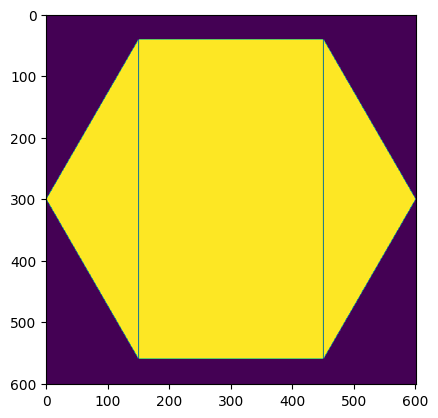

PyObject <matplotlib.image.AxesImage object at 0x7f725fd179d0>

In [130]:
imshow(bzone)

In [133]:
N = 100
epsilons = zeros(N, N)
for j in 1:N
    println(j); flush(stdout)
    qx, qy = -Klevitov + 2Klevitov*j/N, 0
    impol = levitov_im_polarization(qx, qy)
    for i in 1:N
        epsilons[i, j]  = levitov_kramers_kronig_epsilon(qx, qy, 20*i/N, impols = impol)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


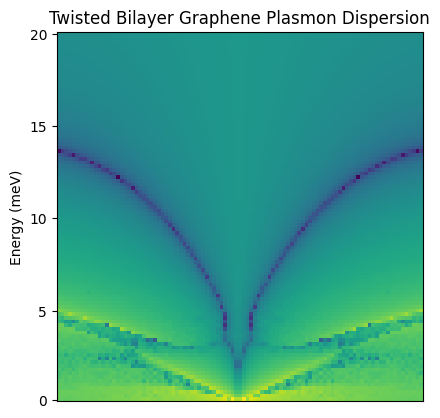

PyObject Text(0.5, 1.0, 'Twisted Bilayer Graphene Plasmon Dispersion')

In [145]:
imshow(log.(abs.(epsilons[:, union(1:49, 51:100)])), origin="lower")
xticks(Float64[])
yticks([0, 24, 49, 74, 99], [0, 5, 10, 15, 20])
ylabel("Energy (meV)")
title("Twisted Bilayer Graphene Plasmon Dispersion")

In [143]:
5/20*100

25.0

In [157]:
N = 50
epsilons_2 = zeros(N, N)
for j in 1:N
    println(j); flush(stdout)
    qx, qy = -Klevitov + 2Klevitov*j/N, 0
    for i in 1:N
        epsilons_2[i, j]  = real(levitov_epsilon(qx, qy, 20*i/N, 0.3, atol=1e-10, rtol=1e-10, maxevals=20000))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


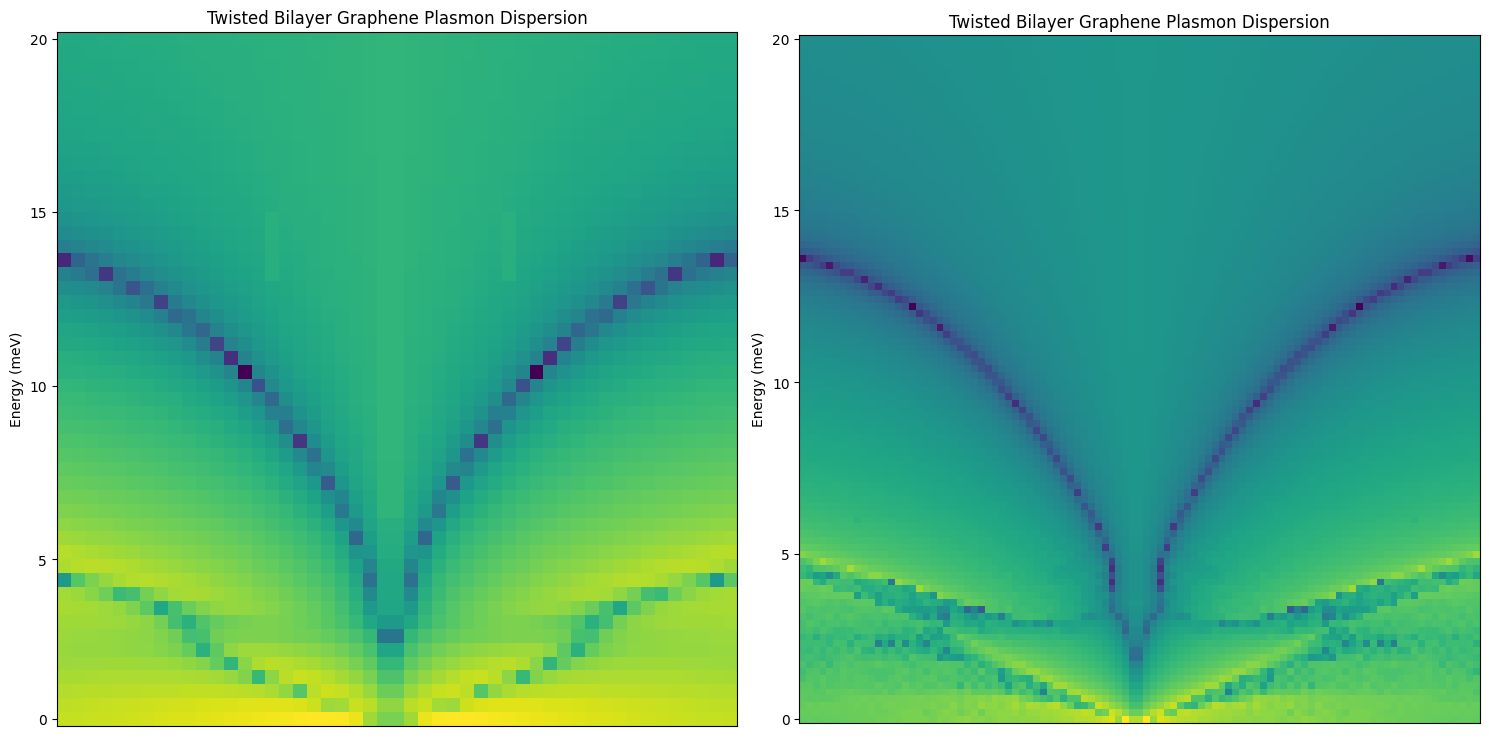

PyObject Text(0.5, 1.0, 'Twisted Bilayer Graphene Plasmon Dispersion')

In [206]:
figure(figsize=(15, 15), frameon=true, tight_layout=true)
subplot(1, 2, 1)
imshow(log.(abs.(epsilons_2[:, union(1:24, 26:50)])), origin="lower")
xticks(Float64[])
yticks([0, 11.5, 24, 36.5, 49], [0, 5, 10, 15, 20])
ylabel("Energy (meV)")
title("Twisted Bilayer Graphene Plasmon Dispersion")
subplot(1, 2, 2)
imshow(log.(abs.(epsilons[:, union(1:49, 51:100)])), origin="lower")
xticks(Float64[])
yticks([0, 24, 49, 74, 99], [0, 5, 10, 15, 20])
ylabel("Energy (meV)")
title("Twisted Bilayer Graphene Plasmon Dispersion")
#tight_layout(pad=2)

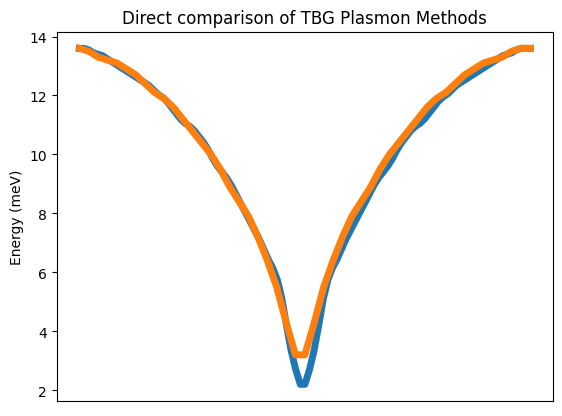

PyObject Text(0.5, 1.0, 'Direct comparison of TBG Plasmon Methods')

In [210]:
plot(range(-1, 1, length=99), 20/100*smooth([argmin(r) for r in eachcol(log.(abs.(epsilons[:, union(1:49, 51:100)])))], win_len=5), linewidth=5)
plot(range(-1, 1, length=49), 20/50*smooth([argmin(r) for r in eachcol(log.(abs.(epsilons_2[:, union(1:24, 26:50)])))], win_len=5), linewidth=5)
ylabel("Energy (meV)")
xticks(Float64[])
title("Direct comparison of TBG Plasmon Methods")

In [189]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Sanity Checks"